In [1]:
import h5py
import numpy as np
import torch
import torchvision
import imageio
import numpy
import torch
from lerobot.common.policies.diffusion.modeling_diffusion import DiffusionPolicy
from lerobot.common.policies.act.modeling_act import ACTPolicy
from lerobot.common.policies.mlp.modeling_mlp import MLPPolicy
from tqdm import tqdm


dataset_path = "/home/shinfang-2f/jay_pick_two_arms_and_hands_sim_20250523_085738/Pick_Right_Arm_and_Hand_Sim_2025-06-12_trimmed.hdf5"

device = "cuda"

In [13]:
dataset_path = "/home/shinfang-2f/jay_pick_two_arms_and_hands_sim_20250523_085738/pick_two_arms_and_hands_sim_1.hdf5"

with h5py.File(dataset_path, "r") as f:
    obs = f['observations']
    print(obs.keys())
    print(obs['images']['la_cam_fix'].shape)
    print(obs['qpos'].shape)      
    print(obs['qvel'].shape)
    
    action = f['action']
    print(action.shape)
    

<KeysViewHDF5 ['images', 'qpos', 'qvel']>
(450, 720, 1280, 3)
(450, 56)
(450, 56)
(450, 56)


In [2]:
torch.manual_seed(0)
np.random.seed(0)


In [2]:
# with h5py.File(dataset_path, "r") as f:
#     demo_key = list(f["data"].keys())[0]
#     demo_group = f["data"][demo_key]
#     obs_group = demo_group["obs"]
#     obs_dict = {"qpos": obs_group["qpos"][0], "qvel": obs_group["qvel"][0]}
#     obs_dict["images"] = obs_group["images"][0]

In [15]:
with h5py.File(dataset_path, "r") as f:
    demo_key = list(f["data"].keys())[2]
    demo = f["data"][demo_key]
    # print(demo.keys())
    obs_group = demo["obs"]
    demo = {"action": demo["actions"][:], "obs": {"qpos": obs_group["qpos"][:], "qvel": obs_group["qvel"][:], "images": obs_group["images"][:]}}


In [16]:
pretrained_policy_path = "/home/shinfang-2f/jay_pick_two_arms_and_hands_sim_20250523_085738/IL/lerobot/approach_ACT/output/checkpoints/last/pretrained_model"
# policy = DiffusionPolicy.from_pretrained(pretrained_policy_path)
# policy = MLPPolicy.from_pretrained(pretrained_policy_path)
policy = ACTPolicy.from_pretrained(pretrained_policy_path)
policy.reset()

gt_actions = []
pred_actions = []

for i in tqdm(range(demo['obs']['images'].shape[0])):
    gt_actions.append(demo['action'][i])
    state = torch.from_numpy(np.concatenate([demo['obs']['qpos'][i], demo['obs']['qvel'][i]]))
    image = torch.from_numpy(demo['obs']["images"][i])

    state = state.to(torch.float32)
    image = image.to(torch.float32) / 255
    image = image.permute(2, 0, 1)

    # resize image to 350x350 with torchvision
    image = torchvision.transforms.Resize(320)(image)
    # # Send data tensors from CPU to GPU
    state = state.to(device, non_blocking=True)
    image = image.to(device, non_blocking=True)

    state = state.unsqueeze(0)
    image = image.unsqueeze(0)

    # Create the policy input dictionary
    observation = {
        "observation.state": state,
        "observation.image": image,
    }

    # Predict the next action with respect to the current observation
    with torch.inference_mode():
        pred_actions.append((policy.select_action(observation)).squeeze(0).cpu().numpy())    

Loading weights from local directory


100%|██████████| 280/280 [00:00<00:00, 1094.62it/s]


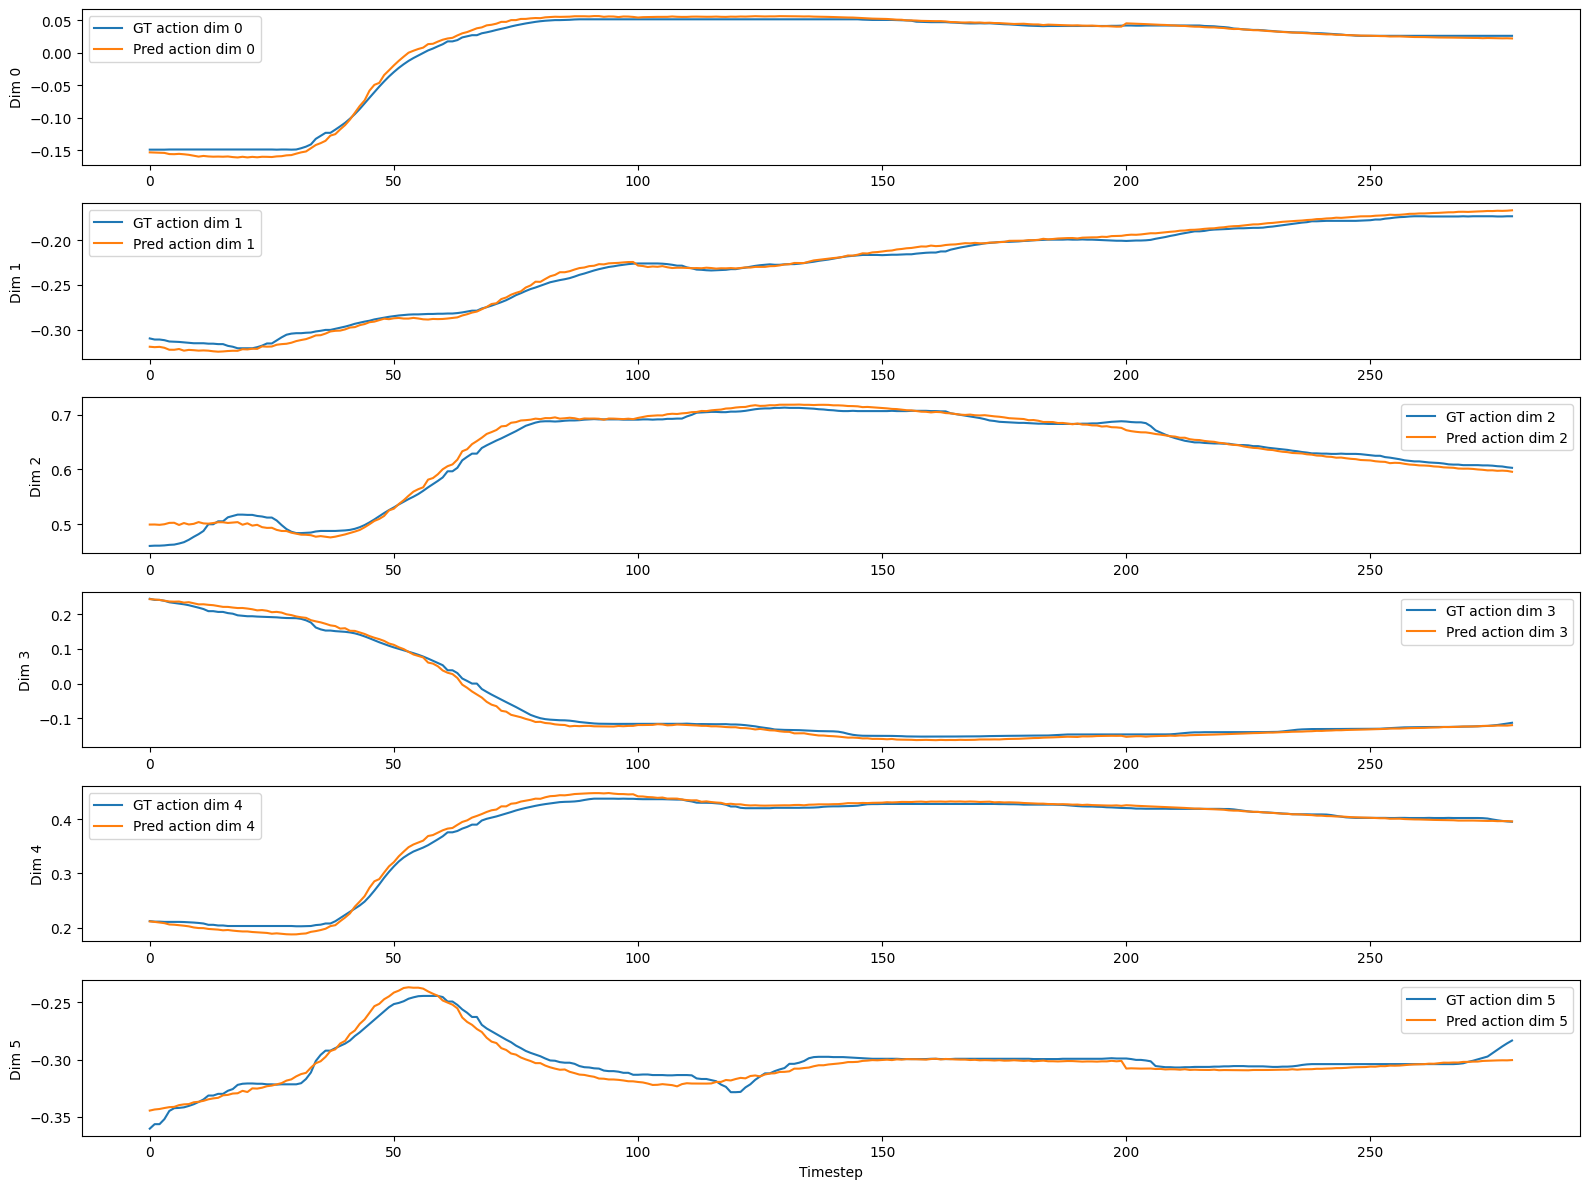

In [17]:
import matplotlib.pyplot as plt
import numpy as np

gt_actions_np = np.stack(gt_actions)  # shape: (N, D)
pred_actions_np = np.stack(pred_actions)  # shape: (N, D)

num_dims = gt_actions_np.shape[1]
plt.figure(figsize=(16, 2 * num_dims))
for d in range(num_dims):
    plt.subplot(num_dims, 1, d + 1)
    plt.plot(gt_actions_np[:, d], label='GT action dim %d' % d)
    plt.plot(pred_actions_np[:, d], label='Pred action dim %d' % d)
    plt.ylabel(f"Dim {d}")
    plt.legend()
plt.xlabel("Timestep")
plt.tight_layout()
plt.show()



In [3]:




state = torch.from_numpy(np.concatenate([obs_dict['qpos'], obs_dict['qvel']]))
image = torch.from_numpy(obs_dict["images"])

# Convert to float32 with image from channel first in [0,255]
# to channel last in [0,1]
state = state.to(torch.float32)
image = image.to(torch.float32) / 255
image = image.permute(2, 0, 1)

# resize image to 350x350 with torchvision
image = torchvision.transforms.Resize(350)(image)
# # Send data tensors from CPU to GPU
state = state.to(device, non_blocking=True)
image = image.to(device, non_blocking=True)

state = state.unsqueeze(0)
image = image.unsqueeze(0)

# Create the policy input dictionary
observation = {
    "observation.state": state,
    "observation.image": image,
}

# Predict the next action with respect to the current observation
with torch.inference_mode():
    action = policy.select_action(observation)

Loading weights from local directory


In [4]:
action.shape

torch.Size([1, 6])

In [5]:
action.squeeze(0).shape

torch.Size([6])